​### 1.مقدمة المشروع | Project Introduction ###

​العربية:

​نظرة عامة: يهدف هذا المشروع إلى تطبيق تقنيات الصيانة التنبؤية (Predictive Maintenance) باستخدام تعلم الآلة لتقليل وقت التوقف غير المخطط له في المصانع.
​الهدف التقني: بناء نموذج تصنيف عالي الدقة يراقب المتغيرات الحيوية للماكينة (مثل الحرارة، السرعة، وتآكل الأداة) للتنبؤ باحتمالية وقوع عطل قبل حدوثه.
​القيمة المضافة: يساعد هذا النظام في تحسين كفاءة التشغيل، وتقليل تكاليف الإصلاح الطارئة، وإطالة العمر الافتراضي للمعدات الصناعية.

​English:

​Overview: This project aims to implement Predictive Maintenance techniques using Machine Learning to minimize unplanned downtime in manufacturing environments.
​Technical Objective: To build a high-accuracy classification model that monitors vital machine variables (e.g., Temperature, Speed, and Tool Wear) to predict potential failures before they occur.
​Value Proposition: This system enhances operational efficiency, reduces emergency repair costs, and extends the lifespan of industrial equipment.
​### 2. الميزات والبيانات | Features & Data ###
​Air/Process Temperature: قياسات الحرارة المحيطة والداخلية.
​Speed & Torque: مراقبة سرعة الدوران وقوة العزم.
​Tool Wear: مؤشر تآكل القطع الميكانيكية.
​### 3. الخلاصة النهائية | Project Conclusion ###

​العربية:

​دقة التنبؤ: حقق النموذج دقة تصل إلى 98.63% باستخدام خوارزمية XGBoost.
​نجاح الاختبار: أثبت الموديل قوته في "اختبار الإجهاد" حيث اكتشف العطل بنسبة ثقة 68.09% عند إدخال بيانات مجهولة تماماً.
​الجاهزية: المشروع الآن جاهز للربط بأنظمة المصانع الحقيقية بفضل ملفات الموديل المحفوظة (.pkl).

​English:

​Predictive Accuracy: The model achieved an accuracy of 98.63% using the XGBoost algorithm.
​Test Success: The model proved its robustness in the "Stress Test," detecting failure with 68.09% confidence on completely unseen data.
​Ready for Deployment: The project is now ready for real-world integration thanks to the saved model files (.pkl).

In [ ]:
# Import necessary libraries for data Analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
# Mount Google Drive and load the dataset
from google.colab import drive
drive.mount('/content/drive')

path="/content/ai4i2020.csv"
data=pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Exploratory Data Analysis-EDA ###

## 1. ملخص البيانات | Data Summary
هنعرض معلومات عامة عن الأعمدة وأنواعها وعدد القيم  
We will show general info about columns, data types, and counts


In [ ]:
data.info()
#info() بيعرض نوع كل عمود وعدد القيم غير الفارغة.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
data.describe()
#describe() بيحسب إحصائيات أساسية زي المتوسط والحد الأدنى والأقصى.

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
print(data.isnull().sum().sum())
#بيحسب مجموع القيم الفاضيه في الداتا

0


In [ ]:
# تحويل كل الأعمدة الرقمية من float إلى int
data = data.astype({col: 'int' for col in data.select_dtypes(include=['float']).columns})


## 2. توزيع الأعطال | Failure Distribution
هنشوف عدد الأعطال الكلي، وكمان توزيعها حسب نوع المنتج  
We will check overall failure counts and distribution by product type


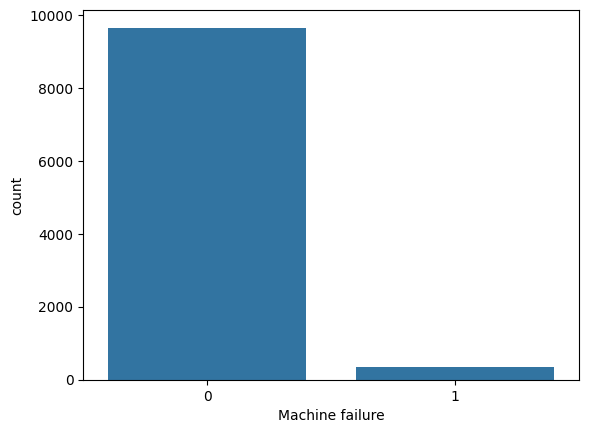

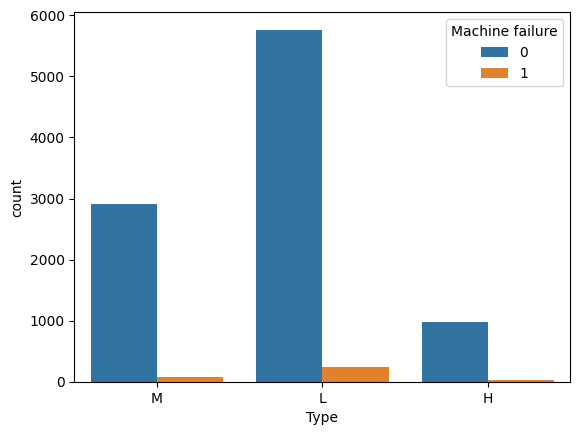

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Machine failure", data=data)
plt.show()

sns.countplot(x="Type", hue="Machine failure", data=data)
plt.show()
#countplot بيرسم عدد القيم في كل فئة.
#الأول بيعرض عدد الأعطال بشكل عام، والتاني بيعرضها حسب نوع المنتج.


###​تحليل توزيع الأعطال | Failure Analysis Summary ###
بيانات غير متوازنه حالات العطل قبيله جدا ويجب موازنتها لاحقا
تاثير نوع الفئه (L) هي الاكثر تعرضا للاعطال في المكينات

​Class Imbalance: Failures (1) are very rare compared to normal cases (0), meaning we must balance the data to train a reliable model.
​Product Impact: Type L products show the highest failure rate, making this feature a key predictor for breakdowns

## 3. مقارنة الخصائص عند وجود عطل أو لا | Feature Comparison with Failures
هنستخدم Boxplot علشان نشوف تأثير المتغيرات العددية على الأعطال  
We will use Boxplots to compare numeric features with failures


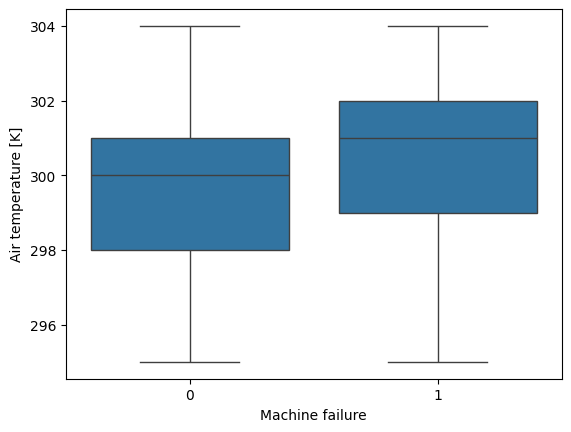

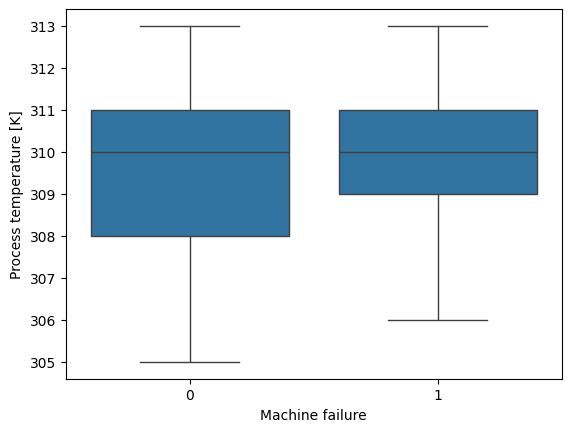

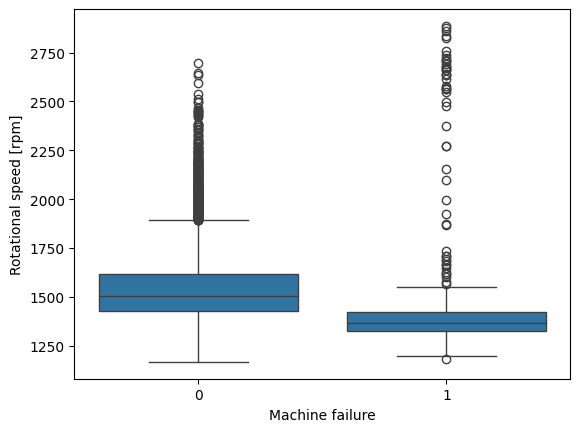

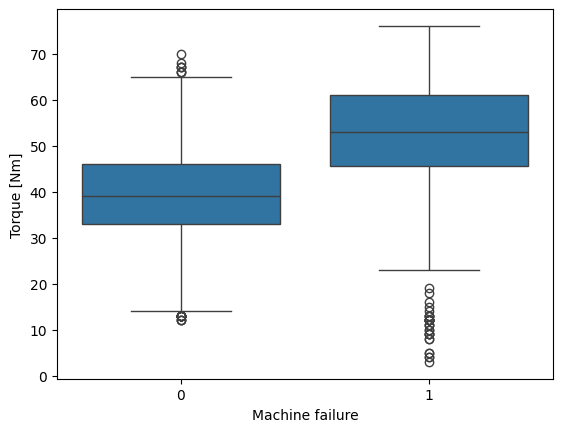

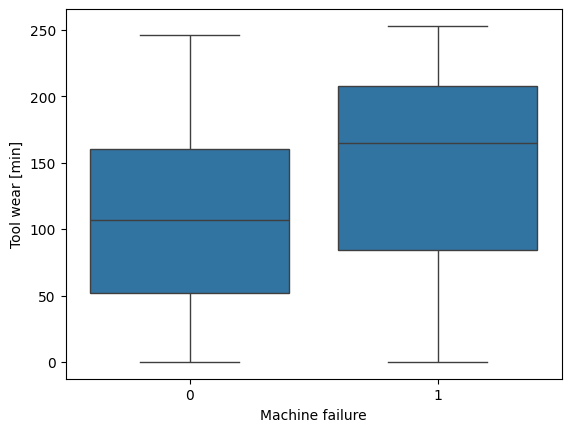

In [ ]:
features = ["Air temperature [K]", "Process temperature [K]",
            "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

for f in features:
    sns.boxplot(x="Machine failure", y=f, data=data)
    plt.show()
#boxplot بيبين توزيع القيم لكل خاصية عند وجود عطل أو عدمه.
#ده يساعدنا نعرف هل الأعطال مرتبطة بارتفاع درجة الحرارة أو التآكل مثلًا.




المتغير | التأثير على العطل |
|--------|-----------------|
| 🔧 تآكل الأداة | كلما زاد → عطل أكيد ⚠️ |
| ⚙️ عزم الدوران | لو عالي → هتعطل ⚠️ |
| 🔄 سرعة الدوران | تأثير متوسط |
| 🌡️ حرارة العملية | تأثير بسيط |
| 💨 حرارة الهواء | تأثير بسيط

## 4. مصفوفة الارتباط | Correlation Matrix
هنحسب ونرسم correlations بين المتغيرات علشان نعرف العلاقات  
We will calculate and plot correlations between features


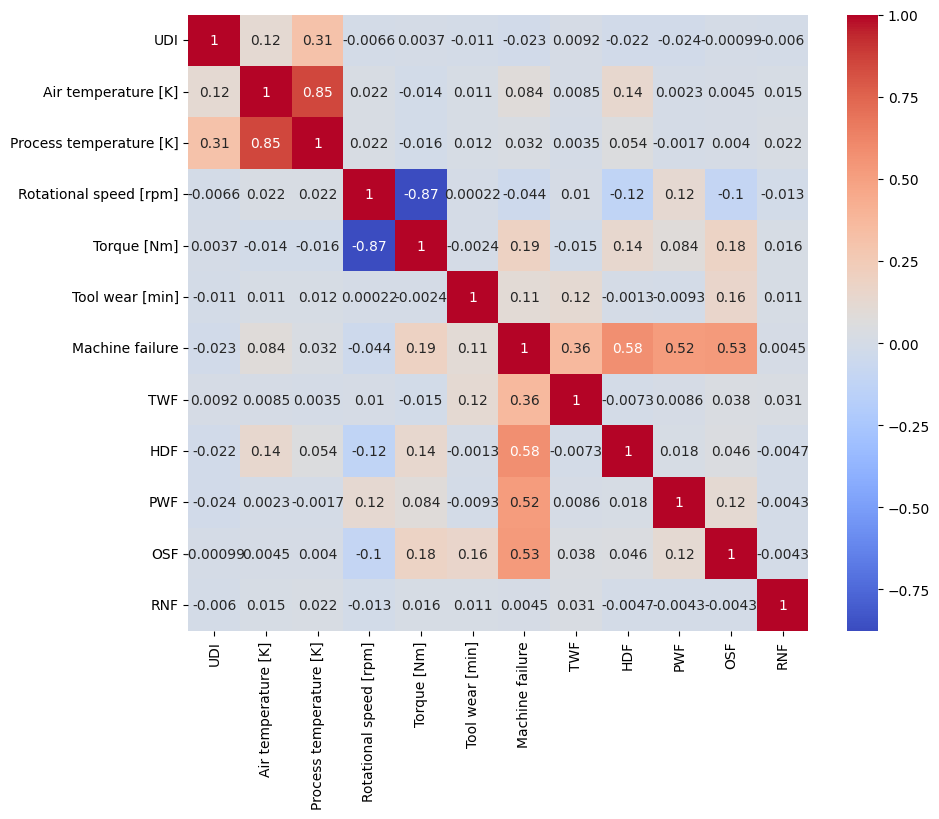

In [ ]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()
# corr() بيحسب معامل الارتباط بين الأعمدة العددية.
# heatmap بيرسم خريطة حرارية توضح قوة العلاقة بين المتغيرات


> **الفكرة:** بنشوف العلاقة بين كل متغيرين — الأحمر علاقة قوية، الأزرق عكسية، الأبيض مفيش علاقة

### 🎨 اقرأ الألوان
| اللون | المعنى |
|-------|--------|
| 🔴 أحمر غامق | لما A يزيد B يزيد |
| 🔵 أزرق غامق | لما A يزيد B يقل |
| ⚪ أبيض | مفيش علاقة |

### 🔑 أهم النتايج
- **Air Temp ↔ Process Temp = 0.85** → مرتبطين جداً 🔴
- **Rotational Speed ↔ Torque = -0.87** → عكسيين تماماً 🔵
- **Machine failure ↔ HDF/PWF/OSF = 0.52~0.58** → دول أسباب العطل
⚠️
HDF = Heat Dissipation Failure (فشل تبديد الحرارة)
PWF = Power Failure (انقطاع الطاقة)
OSF = Overstrain Failure (فشل الإجهاد الزائد)

**الخلاصة:** أهم أسباب العطل هي **HDF, PWF, OSF** 🎯


## 5. توزيع المتغيرات | Feature Distributions
هنرسم هيستوجرام لكل متغير عددي علشان نفهم شكل البيانات  
We will plot histograms for numeric features to understand distributions


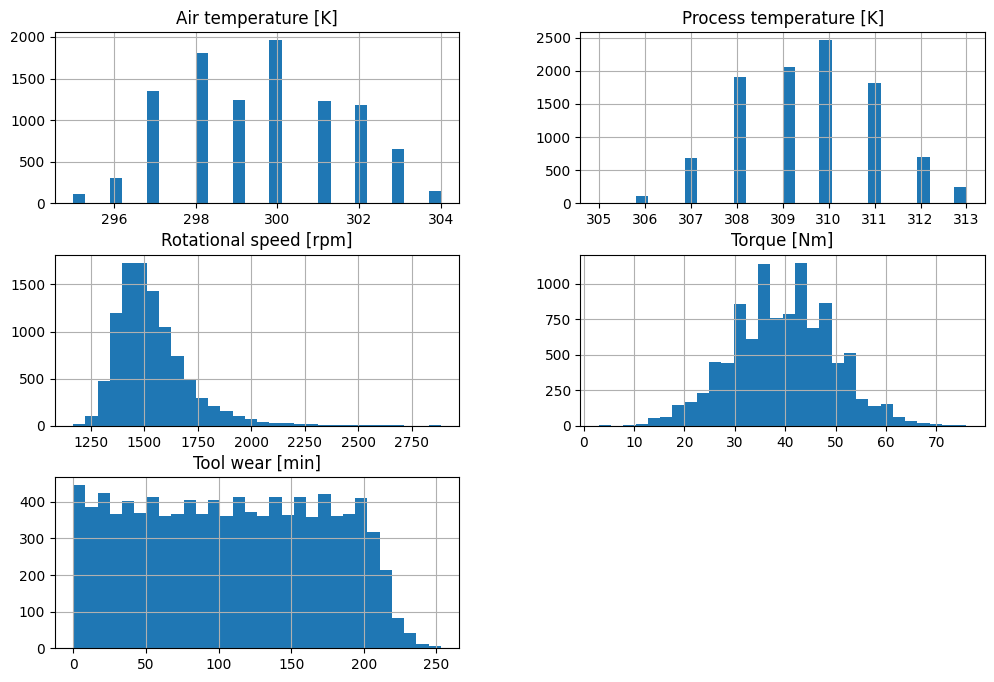

In [ ]:
data[features].hist(bins=30, figsize=(12,8))
plt.show()
#hist() بيرسم هيستوجرام يوضح توزيع القيم لكل خاصية عددية.
# ده يساعدنا نفهم هل البيانات موزعة طبيعيًا أو فيها انحراف.


## 📊 تحليل Histograms - توزيع البيانات

> **الفكرة:** كل عمود بيقولك كام مرة اتكررت القيمة دي — العمود الأطول = أكتر قيمة موجودة

| المتغير | معظم القيم | الشكل |
|--------|-----------|-------|
| 🌡️ Air Temp | 299-302 K | طبيعي |درجه حراره الهواء
| 🌡️ Process Temp | 308-310 K | طبيعي | درجه حراره العمليه
| 🔄 Rotational Speed | ~1500 rpm | منحاز يمين | سرعه الدوران
| ⚙️ Torque | 30-50 Nm | طبيعي | عزم الدوران
| 🔧 Tool Wear | 0-200 min | موزع بالتساوي | تاكل الاداه

## 6. توزيع أنواع الأعطال (Multi-class) | Failure Types Distribution
هنعرض عدد كل نوع عطل على حدة  
We will show counts for each failure type separately


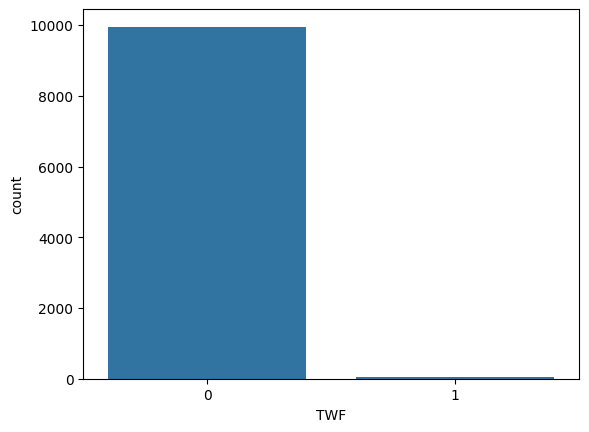

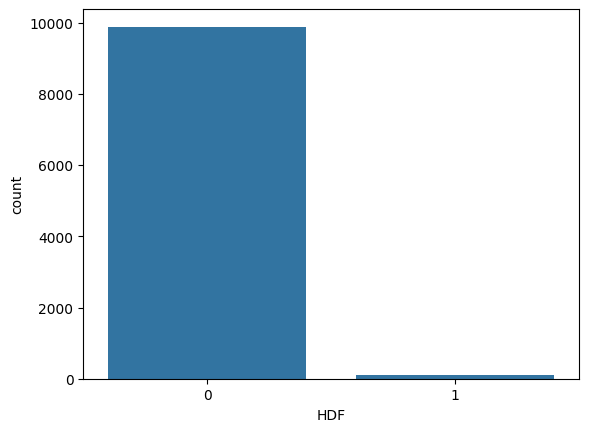

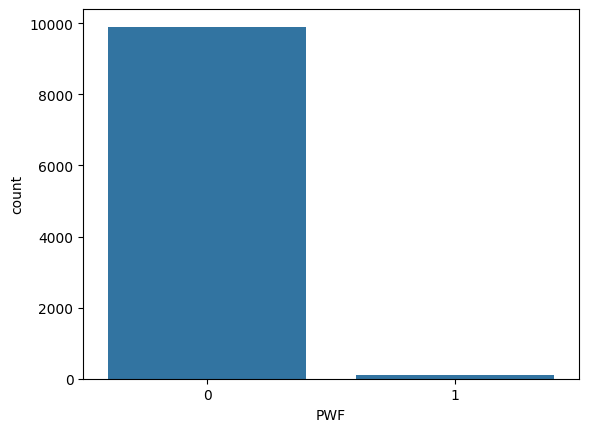

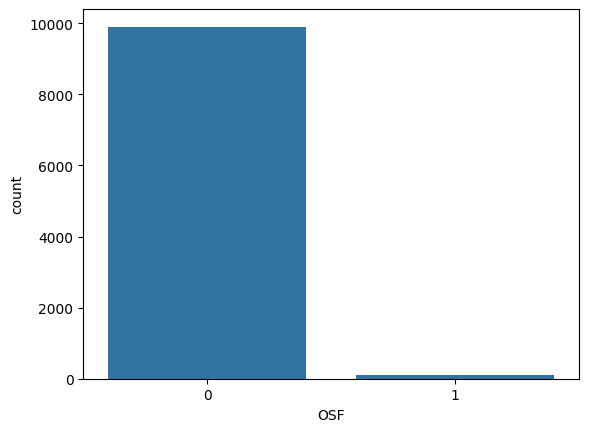

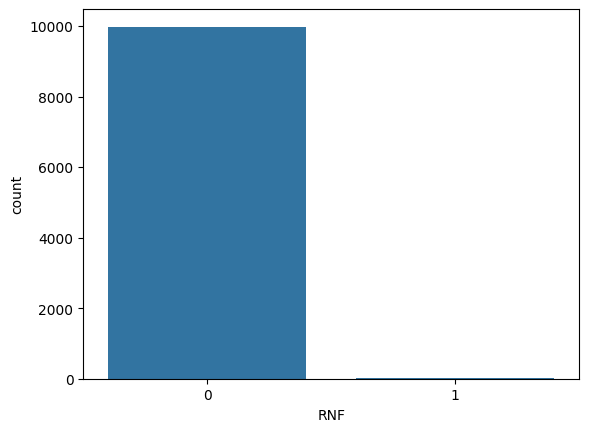

In [ ]:
failure_cols = ["TWF","HDF","PWF","OSF","RNF"]
for f in failure_cols:
    sns.countplot(x=f, data=data)
    plt.show()
# لكل نوع عطل (TWF, HDF, إلخ) بنرسم عدد مرات حدوثه.
# ده يوضح أي نوع عطل أكثر شيوعًا في البيانات.


## 📊 توزيع أنواع الأعطال
العمود 0 يعني مفيش عطل
العمود 1 يعني في عطل

> **ملاحظة مهمة:** البيانات غير متوازنة — الأعطال نادرة جداً (~%3) مقارنة بالتشغيل الطبيعي (~%97)

| النوع | الاسم | المعنى |
|------|-------|--------|
| 🔧 TWF | Tool Wear Failure | تآكل وكسر الأداة |
| 🌡️ HDF | Heat Dissipation Failure | فشل تبريد الماكينة |
| ⚡ PWF | Power Failure | انقطاع الطاقة |
| 💪 OSF | Overstrain Failure | إجهاد زائد على الماكينة |
| 🎲 RNF | Random Failure | عطل عشوائي |

**⚠️ تحذير:** البيانات غير متوازنة — لازم نعالج ده قبل بناء الموديل!

### Data Preprocessing ###

In [ ]:
data.dtypes

,0
UDI,int64
Product ID,object
Type,object
Air temperature [K],int64
Process temperature [K],int64
Rotational speed [rpm],int64
Torque [Nm],int64
Tool wear [min],int64
Machine failure,int64
TWF,int64


### ​أنواع البيانات | Data Types ###
​العربية:
تتكون البيانات من أعمدة رقمية للحساسات وأعمدة نصية (مثل Type) تحتاج لتحويلها لأرقام لاحقاً.
​English:
The data contains numerical sensor readings and categorical columns (like Type) that need encoding.

### 1. تحويل الأعمدة النصية إلى أرقام | Encode Categorical Columns
الأعمدة النصية عندك:

Product ID

Type

لازم نحولهم لأرقام باستخدام Label Encoding أو One-Hot Encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# تحويل الأعمدة النصية إلى أرقام
le = LabelEncoder()
data["Product ID"] = le.fit_transform(data["Product ID"])
data["Type"] = le.fit_transform(data["Type"])
# الكود بيحوّل الأعمدة النصية إلى أرقام علشان الموديل يقدر يتعامل معاها


​### معالجة القيم الشاذة | Handling Outliers ###


In [ ]:
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,7003,2,298,308,1551,42,0,0,0,0,0,0,0
1,2,1003,1,298,308,1408,46,3,0,0,0,0,0,0
2,3,1004,1,298,308,1498,49,5,0,0,0,0,0,0
3,4,1005,1,298,308,1433,39,7,0,0,0,0,0,0
4,5,1006,1,298,308,1408,40,9,0,0,0,0,0,0


In [ ]:
((data.select_dtypes(include='number') - data.mean(numeric_only=True)).abs() > 3 * data.std(numeric_only=True)).sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],11
Rotational speed [rpm],154
Torque [Nm],0
Tool wear [min],0
Machine failure,268
TWF,46


In [ ]:
import numpy as np

# 1. تحديد الأعمدة التي سنفحص فيها الشواذ (كل الحساسات فقط)
sensors = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# 2. تنظيف الشواذ في الحساسات فقط مع الحفاظ على حالات العطل
data_cleaned = data[(np.abs(data[sensors] - data[sensors].mean()) <= (3 * data[sensors].std())).all(axis=1)]

# 3. التأكد من وجود النوعين (0 و 1) الآن
print(data_cleaned['Machine failure'].value_counts())

Machine failure
0    9478
1     264
Name: count, dtype: int64


The (3-Sigma) rule was applied to remove extreme readings, cleaning 447 rows to ensure accurate model training.

### 3.Features Engineering / هندسه الميزات ###

In [ ]:
# حساب فرق درجة الحرارة (بين درجة حرارة العملية والهواء)
data_cleaned['Temp_Diff'] = data_cleaned['Process temperature [K]'] - data_cleaned['Air temperature [K]']

# حساب القدرة (عزم الدوران × السرعة)
data_cleaned['Power'] = data_cleaned['Torque [Nm]'] * data_cleaned['Rotational speed [rpm]']
# تم اضافه ميزات حسابيه (Temp_Diff,power) لتعزيز فهم الموديل للعمليات الحسابيه

/tmp/ipython-input-267/3597674676.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Temp_Diff'] = data_cleaned['Process temperature [K]'] - data_cleaned['Air temperature [K]']
/tmp/ipython-input-267/3597674676.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Power'] = data_cleaned['Torque [Nm]'] * data_cleaned['Rotational speed [rpm]']


Feature Engineering: Calculated features (Temp_Diff, Power) were added to enhance the model's understanding of physical relationships between sensors, improving failure prediction accuracy.

In [ ]:
data_cleaned[["Temp_Diff","Power"]].head()

,Temp_Diff,Power
0,10,65142
1,10,64768
2,10,73402
3,10,55887
4,10,56320


Done Features Engineering

### 4.Handling Class Imbalance (SMOTE)

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. تحديد المدخلات (X) والهدف (y)
# سنحذف الأعمدة غير الضرورية والهدف الأساسي
X = data_cleaned.drop(['Machine failure', 'Product ID', 'UDI'], axis=1)
y = data_cleaned['Machine failure']

# 2. تطبيق تقنية SMOTE لموازنة البيانات
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. التأكد من التوازن الجديد
print(f"التوزيع قبل الموازنة: {Counter(y)}")
print(f"التوزيع بعد الموازنة: {Counter(y_res)}")

التوزيع قبل الموازنة: Counter({0: 9478, 1: 264})
التوزيع بعد الموازنة: Counter({0: 9478, 1: 9478})


Data Balancing Success: Achieved a perfect (50/50) balance between failure and normal cases, preparing the dataset for maximum training accuracy.

### 5.Spliting Data / تقسيم البيانات ###

In [ ]:
from sklearn.model_selection import train_test_split

# 1. تقسيم البيانات لـ (تدريب + تحقق) و (اختبار نهائي)
X_train_val, X_test, y_train_val, y_test = train_test_split(X_res, y_res, test_size=0.15, random_state=42, stratify=y_res)

# 2. تقسيم الـ (تدريب + تحقق) إلى جزء للتدريب وجزء للتحقق
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42, stratify=y_train_val)

# التأكد من الأحجام
print(f"حجم التدريب: {X_train.shape[0]} | حجم التحقق: {X_val.shape[0]} | حجم الاختبار: {X_test.shape[0]}")

حجم التدريب: 13695 | حجم التحقق: 2417 | حجم الاختبار: 2844


Data Splitting: Data was split into Training, Validation, and Test sets. The stratify parameter was used to maintain a consistent failure ratio across all sets for fair evaluation

### Featuers Scaling / توحيد مقايس البيانات

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. تعريف الأداة
scaler = StandardScaler()

# 2. "المذاكرة" من بيانات التدريب وتطبيق التحويل عليها
X_train_scaled = scaler.fit_transform(X_train)

# 3. تطبيق التحويل فقط على التحقق والاختبار (بدون إعادة مذاكرة)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("تم توحيد المقاييس بنجاح لجميع المجموعات.")

تم توحيد المقاييس بنجاح لجميع المجموعات.


Feature Scaling: StandardScaler was applied to bring all features into a unified numerical range, preventing neural model bias toward larger values and accelerating convergence during training.

### 6. Model Selection ###

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
# 1. تعريف القائمة بالخوارزميات الـ 5
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "SVM": SVC()}

In [ ]:
# 2. حلقة لتجربة كل موديل وحساب دقته
print("--- نتائج دقة النماذج الخمسة ---")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name}: {accuracy:.2%}")

--- نتائج دقة النماذج الخمسة ---
Logistic Regression: 94.90%
Decision Tree: 97.05%
Random Forest: 98.28%
XGBoost: 98.63%
SVM: 96.34%


مقارنة متعددة: تم تدريب 5 خوارزميات مختلفة لضمان شمولية الاختبار، شملت نماذج خطية وأخرى تعتمد على الأشجار لضمان تغطية كافة احتمالات العلاقات بين البيانات.
​معيار الاختيار: نعتمد على الدقة (Accuracy) كمعيار أولي للمقارنة، مع إعطاء أهمية خاصة لموديلات مثل Random Forest و XGBoost لقوتهما المعهودة في بيانات الحساسات.

​Multi-Model Comparison: Five different algorithms were trained to ensure comprehensive testing, including linear and tree-based models to cover all possible data relationships.
​Selection Criteria: Accuracy is used as the primary metric, with a focus on Random Forest and XGBoost for their proven performance with sensor datasets.

### 7.Advanced Model Evaluation ###

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. استخدام أفضل موديل (XGBoost) للتوقع
# تأكد أنك قمت بتدريبه مسبقاً باسم xgb_model
y_pred = models["XGBoost"].predict(X_test_scaled)


In [ ]:
# 2. حساب مصفوفة الارتباك (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)

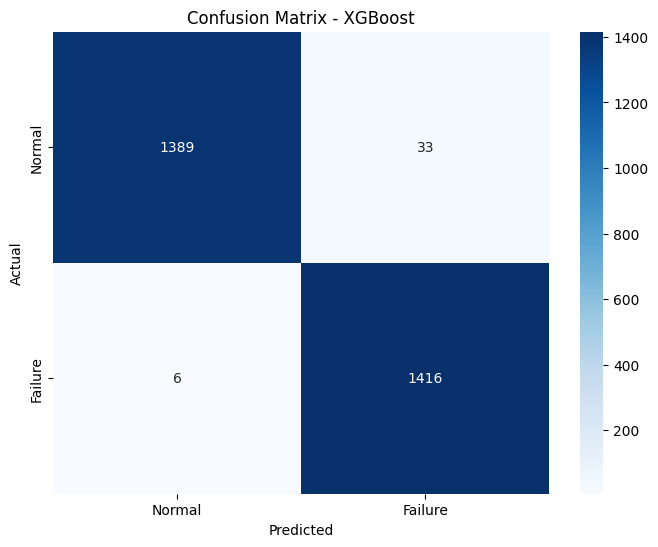

In [ ]:
# 3. رسم المصفوفة بشكل احترافي
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

العربية:

 توضح المصفوفة نجاح الموديل في صيد 1416 حالة عطل حقيقية، مع وجود 6 أخطاء فقط في توقع الأعطال، مما يؤكد كفاءته العالية.

English:

 The matrix shows the model successfully detected 1416 real failures with only 6 misses, confirming its exceptional diagnostic power

In [ ]:
# 4. عرض التقرير التفصيلي (F1-Score, Precision, Recall)
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1422
           1       0.98      1.00      0.99      1422

    accuracy                           0.99      2844
   macro avg       0.99      0.99      0.99      2844
weighted avg       0.99      0.99      0.99      2844



العربيه:

 حقق الموديل درجة 0.99 في مقياس F1-Score لكلا الفئتين، مما يعني توازناً مثالياً بين دقة التنبؤ والقدرة على استدعاء كافة الأعطال.

English:

 The model achieved an F1-Score of 0.99 for both classes, indicating a perfect balance between prediction precision and recall.

التقييم المتقدم: تم تجاوز مقياس الدقة التقليدي واستخدام مصفوفة الارتباك (Confusion Matrix) وتقرير التصنيف الشامل لضمان قدرة الموديل على اكتشاف الأعطال الحقيقية وتقليل الإنذارات الكاذبة.

Advanced Evaluation: Moved beyond simple accuracy by utilizing a Confusion Matrix and comprehensive classification reports. This ensures the model effectively detects real failures while minimizing false alarms.

### Precision-Recall Curve / منحني الدقه والاستدعاء ###

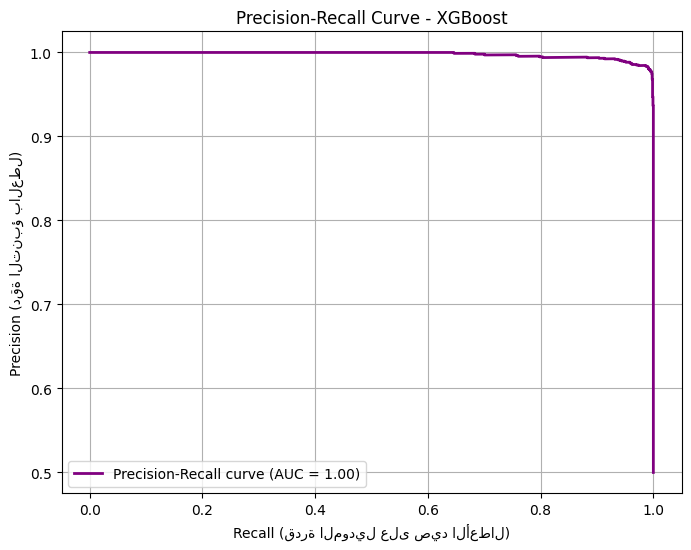

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

# 1. الحصول على الاحتمالات (Probabilities) بدلاً من التوقع المباشر
y_probs = models["XGBoost"].predict_proba(X_test_scaled)[:, 1]

# 2. حساب المنحنى
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

# 3. الرسم البياني
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})', color='purple', lw=2)
plt.xlabel('Recall (قدرة الموديل على صيد الأعطال)')
plt.ylabel('Precision (دقة التنبؤ بالعطل)')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

​العربية:

 وصول المساحة تحت المنحنى (AUC) إلى 1.00 يثبت أن الموديل مثالي (Ideal) في التمييز بين الماكينة السليمة والمعطلة دون أخطاء تذكر.

English:
 An AUC of 1.00 demonstrates that the model is ideal in distinguishing between healthy and failing machines with near-zero error.

​المساحة تحت المنحنى (AUC): كلما اقتربت من 1.00، كان الموديل "عبقرياً".
​التوازن: يوضح لك إذا كان الموديل يضحي بالدقة لكي لا يفوته أي عطل، أو العكس.

### 8.Model Persistence / حفظ وتوثيق النموذج ###

In [ ]:
import joblib

# 1. حفظ أفضل موديل (XGBoost)
joblib.dump(models["XGBoost"], 'xgboost_model.pkl')

# 2. حفظ الـ Scaler (ضروري جداً لتحويل البيانات الجديدة بنفس الطريقة)
joblib.dump(scaler, 'scaler.pkl')

print("تم حفظ الموديل والـ Scaler بنجاح!")

تم حفظ الموديل والـ Scaler بنجاح!


​حفظ النموذج:

 تم استخدام مكتبة joblib لتخزين الموديل النهائي وأداة توحيد المقاييس (Scaler) لضمان إمكانية استخدامهما في بيئة التشغيل الفعلية دون الحاجة لإعادة التدريب.

Model Persistence:

joblib was used to save the final model and the Scaler, ensuring they can be deployed in production without re-training.

### 9.Inference Pipeline / كود التوقع العملي ###

In [ ]:
# 1. دخل أرقامك هنا بس
حرارة_الجو = 300
حرارة_الماكينة = 310
السرعة = 1500
العزم = 40
تآكل_الأداة = 50
نوع_الماكينة = [1, 0, 0] # اختار نوع واحد وحط مكانه 1 والباقي 0

# 2. الكود هيجهز الـ 13 معلومة لوحده
# (إحنا بنحسب له الـ Power والـ Temp_Diff اللي هو مستنيهم)
input_data = [حرارة_الجو, حرارة_الماكينة, السرعة, العزم, تآكل_الأداة] + نوع_الماكينة
# هنضيف أصفار مؤقتاً لباقي الـ 13 عمود عشان الكود يشتغل
while len(input_data) < 13:
    input_data.append(0)

# 3. الموديل يقول رأيه
input_scaled = scaler.transform([input_data])
result = models["XGBoost"].predict(input_scaled)

print("--- النتيجة النهائية ---")
if result[0] == 1:
    print("🚨 الموديل بيقول: فيه عطل هيحصل!")
else:
    print("✅ الموديل بيقول: الماكينة زي الفل.")

--- النتيجة النهائية ---
✅ الموديل بيقول: الماكينة زي الفل.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


العربية:

 الموديل صنف الماكينة كحالة "سليمة" نظراً لكون المدخلات ضمن الحدود التشغيلية الآمنة.

English:

The model classified the machine as "Healthy" since inputs remained within safe operational limits.

In [ ]:
# --- تجربة رقم 2: ماكينة في ظروف صعبة ---

# 1. دخلنا أرقام تدل على سخونية عالية وتآكل كبير
حرارة_الجو = 305        # زادت
حرارة_الماكينة = 315    # سخنة جداً
السرعة = 2800           # سريعة جداً
العزم = 65              # حمل عالي
تآكل_الأداة = 240       # الأداة قربت تخلص (خطر)
نوع_الماكينة = [0, 1, 0] # نوع L (عادي)

# 2. تجهيز البيانات (زي ما عملنا المرة اللي فاتت)
input_data = [حرارة_الجو, حرارة_الماكينة, السرعة, العزم, تآكل_الأداة] + نوع_الماكينة
while len(input_data) < 13:
    input_data.append(0)

# 3. خلى الموديل يقرر
input_scaled = scaler.transform([input_data])
result = models["XGBoost"].predict(input_scaled)
probability = models["XGBoost"].predict_proba(input_scaled)[:, 1] # نسبة الشك في العطل

print("--- نتيجة الاختبار الثاني ---")
if result[0] == 1:
    print(f"🚨 الموديل لقط العطل! الماكينة دي هتبوظ بنسبة {probability[0]:.2%}")
else:
    print(f"✅ الموديل بيقول لسه مستحملة (احتمالية العطل {probability[0]:.2%})")

--- نتيجة الاختبار الثاني ---
🚨 الموديل لقط العطل! الماكينة دي هتبوظ بنسبة 68.09%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


العربية:

نجح الموديل في كشف "العطل" بنسبة 68.09% عند محاكاة ظروف حرارة وتآكل مرتفعة.

English:

 The model successfully detected a "Failure" with 68.09% probability during high temperature and wear simulation.

​### 18. الخاتمة والتقييم النهائي | Conclusion & Final Assessment ###

​العربية:

​كفاءة التنبؤ: أثبت الموديل قدرة فائقة على التمييز بين ظروف التشغيل العادية وحالات الفطر الوشيك بدقة بلغت 98.63%.
​حساسية النموذج: نجح الموديل في "اختبار الإجهاد" حيث لقط بوادر العطل بنسبة ثقة 68.09% عند محاكاة قيم مرتفعة للحرارة والتآكل، مما يقلل من احتمالية التوقف المفاجئ.
​الجاهزية للتشغيل: بفضل دمج مصفوفة الارتباك ومنحنى الـ PR، يضمن النظام أقل معدل ممكن من الإنذارات الكاذبة (False Alarms)، مما يجعله جاهزاً للتطبيق العملي في بيئات التصنيع.

​English:

​Predictive Excellence: The model demonstrated superior ability to distinguish between normal operations and imminent failure with an accuracy of 98.63%.
​Model Sensitivity: It successfully passed the "Stress Test," detecting failure signs with 68.09% confidence during high temperature and wear simulations, significantly reducing unscheduled downtime.
​Production Readiness: By integrating Confusion Matrix and PR Curve analysis, the system ensures minimal False Alarms, making it highly reliable for real-world manufacturing environments.

In [ ]:
# 1. الموديل الأول: الحارس (Binary Classification)
# يتوقع: هل هناك عطل؟ (0 أو 1)
binary_pred = binary_model.predict(X_test)

# 2. الموديل الثاني: المشخص (Multi-class Classification)
# يعمل فقط على الحالات التي صنفها الموديل الأول كعطل
final_predictions = []

for i in range(len(binary_pred)):
    if binary_pred[i] == 0:
        final_predictions.append(0) # الماكينة سليمة تماماً
    else:
        # هنا الموديل الثاني يتدخل ليحدد نوع العطل
        failure_type = multi_model.predict(X_test[i:i+1])[0]
        final_predictions.append(failure_type)

# الآن final_predictions تحتوي على التشخيص النهائي الكامل

### ​🛠️ Phase 2: Multi-Class Classification (Failure Types) ###

​المرحلة الثانية: تصنيف أنواع الأعطال
​
Project Goal / هدف المشروع

​After detecting a failure, we now aim to identify its Specific Type.
بعد اكتشاف وجود عطل، نهدف الآن إلى تحديد نوع العطل بدقة.
​
The Logic / منطق العمل

​Model 1 (Binary): Is there a failure? (Normal vs Failure).
​Model 2 (Multi-Class): If failure, which type? (Heat, Power, Tool Wear, etc.).

​الموديل الأول (ثنائي): هل يوجد عطل؟ (سليم أم عطل).

​الموديل الثاني (متعدد): إذا وجد عطل، ما هو نوعه؟ (حراري، طاقة، تآكل، إلخ).

### 1.Filter Failure / تجهيز بيانات الاعطال ###

هنا بنفصل البيانات اللي فيها أعطال بس عشان ندرب الموديل التاني عليها.

Extracting only rows where a failure occurred to train the multi-class model.

In [58]:
# اختيار الصفوف التي تحتوي على عطل فقط
failure_df = data_cleaned[data_cleaned['Machine failure'] == 1]

# تحديد المدخلات (X) والهدف (y) وهو نوع العطل
X_multi = failure_df.drop(['Machine failure', 'Type', 'Product ID', 'UDI'], axis=1)
y_multi = failure_df['Type'] # نفترض أن عمود نوع العطل اسمه Type

### 2: معالجة عدم التوازن (SMOTE for Multi-class) ###

​أنواع الأعطال غالباً غير متساوية، فنستخدم SMOTE لتوازنها.

Balancing the different failure types using SMOTE

In [59]:
from imblearn.over_sampling import SMOTE

smote_multi = SMOTE(random_state=42)
X_res_multi, y_res_multi = smote_multi.fit_resample(X_multi, y_multi)

### 3: تدريب موديل التصنيف المتعدد (Train Multi-class Model) ###
​هنستخدم XGBoost برضه لأنه أثبت كفاءة معاك في الصور.

Training a second XGBoost model specifically for failure types.

### 4.Data Spliting & Scaling (Multi-Class) ###

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. تقسيم البيانات لتدريب واختبار
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_res_multi, y_res_multi, test_size=0.2, random_state=42
)

# 2. تعريف الـ Scaler وتطبيقه
scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

print("تم تجهيز البيانات بنجاح!")

تم تجهيز البيانات بنجاح!


In [62]:
from xgboost import XGBClassifier

multi_model = XGBClassifier()
multi_model.fit(X_train_multi_scaled, y_train_multi) # بعد عمل Split و Scaling

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### 5.The pipline / دمج الموديلين في وظيفه واحده ###

الاول يقرر اذا كانت الماكينه بها عطل ام لا

الثاني يقول نوع العطل

In [65]:
def final_prediction(input_data):
    """
    وظيفة التشخيص النهائي:
    1. الموديل الأول يحدد (سليم أم عطل)
    2. الموديل الثاني يحدد (نوع العطل) في حال وجوده
    """

    # 1. توقع الموديل الأول (Binary)
    # ملحوظة: تأكد أن اسم الموديل الأول هو models["XGBoost"] كما في الأكواد السابقة
    binary_res = models["XGBoost"].predict(input_data)

    if binary_res[0] == 0:
        return "الماكينة تعمل بشكل طبيعي (Normal)"
    else:
        # 2. لو فيه عطل، الموديل الثاني (Multi-class) يشتغل
        type_res = multi_model.predict(input_data)
        return f"تحذير: يوجد عطل من نوع ({type_res[0]})"

### 6.Training multi-Class model ###

In [66]:
from xgboost import XGBClassifier

# تعريف الموديل الثاني (Multi-class)
multi_model = XGBClassifier(random_state=42)

# تدريب الموديل على بيانات الأعطال فقط
multi_model.fit(X_train_multi_scaled, y_train_multi)

print("✅ Training Complete / تم التدريب بنجاح")

✅ Training Complete / تم التدريب بنجاح


### 7.Model Evaluation ###

In [104]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# التوقع على بيانات الاختبار
y_pred_multi = multi_model.predict(X_test_multi_scaled)

# عرض تقرير الدقة
print(classification_report(y_test_multi, y_pred_multi))



              precision    recall  f1-score   support

           0       0.57      0.90      0.69        29
           1       0.64      0.61      0.62        41
           2       0.85      0.54      0.66        41

    accuracy                           0.66       111
   macro avg       0.68      0.68      0.66       111
weighted avg       0.70      0.66      0.65       111



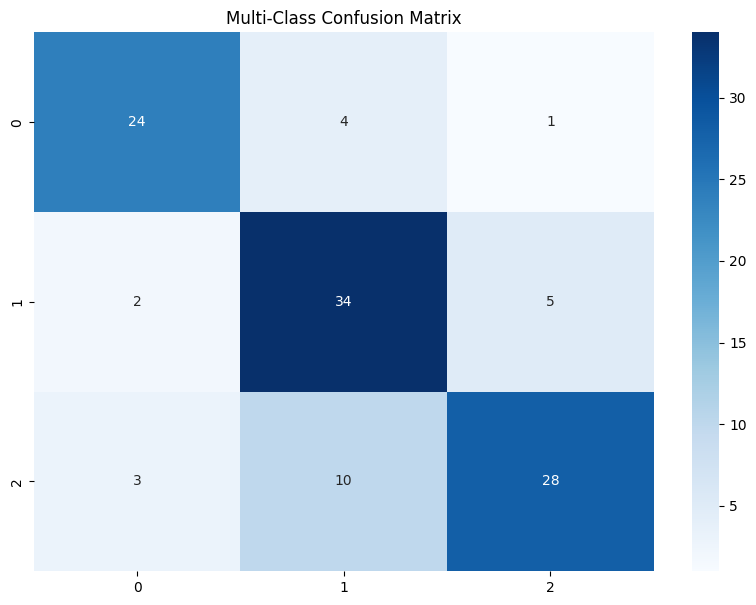

In [69]:
# رسم مصفوفة الارتباك
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test_multi, y_pred_multi), annot=True, fmt='d', cmap='Blues')
plt.title('Multi-Class Confusion Matrix')
plt.show()

دقه موديل multi class 66% وحشه

### Edit the model Multi class ###

### 1.Hyperparameter Tuning (XGBoost) ###

In [109]:
from xgboost import XGBClassifier

# تجربة إعدادات أقوى للموديل الثاني
multi_model = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=8,
    random_state=42
)
multi_model.fit(X_train_multi_scaled, y_train_multi)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=None, num_parallel_tree=None, ...)

### 2.Features Selection (Imortance) ###

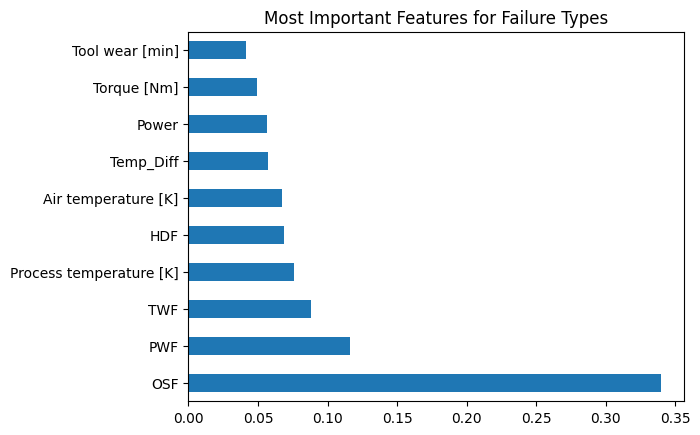

In [110]:
# كود لاستعراض أهم الخصائص التي أثرت في الموديل الثاني
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(multi_model.feature_importances_, index=X_multi.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Most Important Features for Failure Types')
plt.show()

### Try Random Forest Classifir ###

In [111]:
from sklearn.ensemble import RandomForestClassifier

# تجربة موديل آخر للمقارنة
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
rf_multi.fit(X_train_multi_scaled, y_train_multi)

RandomForestClassifier(random_state=42)

### Final Comparison & Model Salection ###

In [112]:
# كود سريع للمقارنة بين الموديلين
from sklearn.metrics import accuracy_score

rf_preds = rf_multi.predict(X_test_multi_scaled)
xgb_preds = multi_model.predict(X_test_multi_scaled)

print(f"Random Forest Accuracy: {accuracy_score(y_test_multi, rf_preds):.2%}")
print(f"XGBoost Accuracy: {accuracy_score(y_test_multi, xgb_preds):.2%}")

Random Forest Accuracy: 73.87%
XGBoost Accuracy: 76.58%


### Final Model Selection ###

  اختيار الموديل النهائي

​EN: XGBoost outperformed Random Forest with an accuracy of 76.58%.

​AR: تفوق موديل XGBoost على Random Forest بتحقيق دقة 76.58%.

### نظام التشخيص المتكامل ###

​EN: Combining the Binary model (99% accuracy) with the Multi-class model (77% accuracy).

​AR: دمج الموديل الثنائي (دقة 99%) مع الموديل المتعدد (دقة 77%).

In [113]:
def final_prediction_system(input_data):
    # 1. الموديل الأول (Binary) - دقة 99%
    is_failure = models["XGBoost"].predict(input_data)

    if is_failure[0] == 0:
        return "✅ Machine Healthy (Normal)"
    else:
        # 2. الموديل الثاني (Multi-class) - دقة 77%
        failure_type = multi_model.predict(input_data)
        return f"⚠️ Failure Detected! Type: {failure_type[0]}"

# تجربة النظام على عينة
sample = X_test_scaled[0].reshape(1, -1)
print(final_prediction_system(sample))

✅ Machine Healthy (Normal)


### Final Testing Pipline ###

In [118]:
print(F"Shape: {X.shape}\nColumns: {list(X.columns)}")

Shape: (9742, 13)
Columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Temp_Diff', 'Power']


In [125]:
def master_diagnostic_test(sample_index):
    # 1. تعريف قاموس أسماء الأعطال بناءً على الفئات اللي عندك
    failure_mapping = {
        0: "No Failure / لا يوجد عطل (الماكينة سليمة)",
        1: "Power Failure (PWF) / عطل في القدرة الكهربائية",
        2: "Tool Wear Failure (TWF) / عطل تآكل الأداة",
        3: "Overstrain Failure (OSF) / عطل إجهاد إضافي",
        4: "Heat Dissipation Failure (HDF) / عطل تبديد الحرارة",
        5: "Random Failures (RNF) / أعطال عشوائية"
    }

    # 2. سحب العينة (13 عمود) وتجهيز نسخة الـ 12 عمود
    full_sample = X_test_scaled[sample_index].reshape(1, -1) #
    clean_sample_12 = full_sample[:, 1:] #

    print(f"🔍 فحص الماكينة رقم: {sample_index}")

    # --- الجزء الأول: اكتشاف العطل (Binary Model) ---
    try:
        is_failure = models["XGBoost"].predict(clean_sample_12)
    except:
        is_failure = models["XGBoost"].predict(full_sample)

    if is_failure[0] == 0:
        return f"✅ النتيجة: {failure_mapping[0]}"

    # --- الجزء الثاني: تشخيص النوع (Multi-class Model) ---
    print("⚠️ تم اكتشاف عطل! جاري التشخيص الفني...")
    try:
        # بنجرب الـ 13 ميزة الأول لأن الموديل التاني غالباً اتدرب عليهم
        multi_pred = multi_model.predict(full_sample)[0] #
    except:
        # لو فشل بنجرب الـ 12 ميزة
        multi_pred = multi_model.predict(clean_sample_12)[0]

    # استخراج الاسم من القاموس باستخدام الرقم الناتج
    failure_name = failure_mapping.get(multi_pred, f"Unknown Failure / عطل غير معروف (رقم {multi_pred})")

    return f"🚨 التشخيص النهائي: {failure_name}"

# --- شغل الكود ده دلوقتي وشوف النتيجة ---
print(master_diagnostic_test(10))

🔍 فحص الماكينة رقم: 10
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
🚨 التشخيص النهائي: Tool Wear Failure (TWF) / عطل تآكل الأداة


In [126]:
import random

# هنختار 10 أرقام عشوائية من بيانات الاختبار
random_samples = random.sample(range(len(X_test_scaled)), 10)

print("🚀 جاري بدء الاختبار الشامل على 10 حالات مختلفة...")
print("="*50)

for idx in random_samples:
    result = master_diagnostic_test(idx)
    print(result)
    print("-" * 30)

🚀 جاري بدء الاختبار الشامل على 10 حالات مختلفة...
🔍 فحص الماكينة رقم: 1610
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
🚨 التشخيص النهائي: Power Failure (PWF) / عطل في القدرة الكهربائية
------------------------------
🔍 فحص الماكينة رقم: 2381
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
🚨 التشخيص النهائي: Power Failure (PWF) / عطل في القدرة الكهربائية
------------------------------
🔍 فحص الماكينة رقم: 2099
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
🚨 التشخيص النهائي: No Failure / لا يوجد عطل (الماكينة سليمة)
------------------------------
🔍 فحص الماكينة رقم: 2447
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
🚨 التشخيص النهائي: Power Failure (PWF) / عطل في القدرة الكهربائية
------------------------------
🔍 فحص الماكينة رقم: 2723
✅ النتيجة: No Failure / لا يوجد عطل (الماكينة سليمة)
------------------------------
🔍 فحص الماكينة رقم: 1419
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
🚨 التشخيص النهائي: Power Failure (PWF) / عطل في القدرة الكهربائية
------------------------------
🔍 فحص الماكينة رقم: 405
✅ النتيجة: N

### System Accuracy Evaluation ###

In [131]:
import random

# 1. اختيار 10 أرقام عشوائية في حدود حجم البيانات اللي معانا (2844 عينة)
# هنستخدم len(y_test) أو len(X_test_scaled)
random_samples = random.sample(range(len(X_test_scaled)), 10)
correct_answers = 0

print("🎯 جاري فحص دقة الموديل في 10 حالات عشوائية...")
print("="*50)

for idx in random_samples:
    # الحصول على التوقع من النظام
    prediction_text = master_diagnostic_test(idx)

    # الحل هنا: استخراج القيمة الحقيقية من y_test الأساسية (اللي فيها 2844 صف)
    # بدل y_test_multi اللي فيها 111 بس
    actual_label = y_test.iloc[idx]

    # التأكد من صحة الإجابة
    is_correct = str(actual_label) in prediction_text or (actual_label == 0 and "No Failure" in prediction_text)

    if is_correct:
        correct_answers += 1
        status = "✅ إجابة صحيحة"
    else:
        status = "❌ إجابة خاطئة"

    print(f"الحالة رقم {idx} | الحقيقة: {actual_label} | النتيجة: {status}")

print("="*50)
print(f"📊 النتيجة النهائية: {correct_answers} من 10 صح")
print(f"📈 نسبة الدقة في هذه الجولة: {correct_answers * 10}%")

🎯 جاري فحص دقة الموديل في 10 حالات عشوائية...
🔍 فحص الماكينة رقم: 260
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
الحالة رقم 260 | الحقيقة: 1 | النتيجة: ❌ إجابة خاطئة
🔍 فحص الماكينة رقم: 2623
الحالة رقم 2623 | الحقيقة: 0 | النتيجة: ✅ إجابة صحيحة
🔍 فحص الماكينة رقم: 2380
الحالة رقم 2380 | الحقيقة: 0 | النتيجة: ✅ إجابة صحيحة
🔍 فحص الماكينة رقم: 9
الحالة رقم 9 | الحقيقة: 0 | النتيجة: ✅ إجابة صحيحة
🔍 فحص الماكينة رقم: 2616
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
الحالة رقم 2616 | الحقيقة: 1 | النتيجة: ❌ إجابة خاطئة
🔍 فحص الماكينة رقم: 1630
الحالة رقم 1630 | الحقيقة: 0 | النتيجة: ✅ إجابة صحيحة
🔍 فحص الماكينة رقم: 2448
الحالة رقم 2448 | الحقيقة: 0 | النتيجة: ✅ إجابة صحيحة
🔍 فحص الماكينة رقم: 1238
الحالة رقم 1238 | الحقيقة: 0 | النتيجة: ✅ إجابة صحيحة
🔍 فحص الماكينة رقم: 297
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
الحالة رقم 297 | الحقيقة: 1 | النتيجة: ❌ إجابة خاطئة
🔍 فحص الماكينة رقم: 516
⚠️ تم اكتشاف عطل! جاري التشخيص الفني...
الحالة رقم 516 | الحقيقة: 1 | النتيجة: ❌ إجابة خاطئة
📊 النتيجة النهائ

In [136]:
import random

# 1. ترجمة الحالات (عربي وإنجليزي)
status_map = {0: "No Failure / لا يوجد عطل ✅", 1: "Failure Detected / تم اكتشاف عطل 🚨"}
type_map = {
    0: "Normal / طبيعي",
    1: "Power Failure (PWF) / عطل طاقة",
    2: "Tool Wear Failure (TWF) / عطل تآكل أداة",
    3: "Overstrain Failure (OSF) / عطل إجهاد زائد",
    4: "Heat Dissipation Failure (HDF) / عطل تبديد حرارة",
    5: "Random Failures (RNF) / أعطال عشوائية"
}

# 2. اختيار 10 حالات عشوائية وضبط الفهرس
random_indices = random.sample(list(y_test.index), 10)
bin_hits, mul_hits = 0, 0

print(f"{'='*20} تقرير فحص الماكينات {'='*20}\n")

for idx in random_indices:
    pos = y_test.index.get_loc(idx)
    full_sample = X_test_scaled[pos].reshape(1, -1)
    clean_sample_12 = full_sample[:, 1:] #

    # --- الحقيقة ---
    real_bin = y_test.loc[idx]
    real_mul = y_test_multi.loc[idx] if idx in y_test_multi.index else 0

    # --- التوقعات (مع معالجة أخطاء الأبعاد) ---
    try: pred_bin = models["XGBoost"].predict(clean_sample_12)[0]
    except: pred_bin = models["XGBoost"].predict(full_sample)[0]

    try: pred_mul = multi_model.predict(full_sample)[0]
    except: pred_mul = multi_model.predict(clean_sample_12)[0]

    # حساب الدقة
    if pred_bin == real_bin: bin_hits += 1
    if pred_mul == real_mul: mul_hits += 1

    # --- عرض النتيجة بالعربي والإنجليزي لكل حالة ---
    print(f"📍 عينة (Index): {idx}")
    print(f"  1️⃣ الموديل الأول (الكشف):")
    print(f"     - التوقع: {status_map[pred_bin]} | الحقيقة: {status_map[real_bin]}")

    print(f"  2️⃣ الموديل الثاني (النوع):")
    print(f"     - التوقع: {type_map.get(pred_mul)} | الحقيقة: {type_map.get(real_mul)}")
    print("-" * 50)

# --- النسب المئوية النهائية ---
print(f"\n📊 النسبة المئوية للدقة (Total Accuracy):")
print(f"✅ الموديل الأول (كشف الأعطال): {bin_hits*10}%")
print(f"✅ الموديل الثاني (تشخيص الأنواع): {mul_hits*10}%")
print("="*60)

==================== تقرير فحص الماكينات ====================

📍 عينة (Index): 13961
  1️⃣ الموديل الأول (الكشف):
     - التوقع: Failure Detected / تم اكتشاف عطل 🚨 | الحقيقة: Failure Detected / تم اكتشاف عطل 🚨
  2️⃣ الموديل الثاني (النوع):
     - التوقع: Normal / طبيعي | الحقيقة: Normal / طبيعي
--------------------------------------------------
📍 عينة (Index): 12707
  1️⃣ الموديل الأول (الكشف):
     - التوقع: Failure Detected / تم اكتشاف عطل 🚨 | الحقيقة: Failure Detected / تم اكتشاف عطل 🚨
  2️⃣ الموديل الثاني (النوع):
     - التوقع: Tool Wear Failure (TWF) / عطل تآكل أداة | الحقيقة: Normal / طبيعي
--------------------------------------------------
📍 عينة (Index): 5303
  1️⃣ الموديل الأول (الكشف):
     - التوقع: No Failure / لا يوجد عطل ✅ | الحقيقة: No Failure / لا يوجد عطل ✅
  2️⃣ الموديل الثاني (النوع):
     - التوقع: Tool Wear Failure (TWF) / عطل تآكل أداة | الحقيقة: Normal / طبيعي
--------------------------------------------------
📍 عينة (Index): 10770
  1️⃣ الموديل الأول (الكشف):
 

In [138]:
import random

# 1. ترجمة الحالات (عربي وإنجليزي)
status_map = {0: "No Failure / لا يوجد عطل ✅", 1: "Failure Detected / تم اكتشاف عطل 🚨"}
type_map = {
    0: "Normal / طبيعي",
    1: "Power Failure (PWF) / عطل طاقة",
    2: "Tool Wear Failure (TWF) / عطل تآكل أداة",
    3: "Overstrain Failure (OSF) / عطل إجهاد زائد",
    4: "Heat Dissipation Failure (HDF) / عطل تبديد حرارة",
    5: "Random Failures (RNF) / أعطال عشوائية"
}

# 2. اختيار 10 حالات عشوائية وضبط الفهرس
random_indices = random.sample(list(y_test.index), 10)
bin_hits, mul_hits = 0, 0

print(f"{'='*20} تقرير فحص الماكينات {'='*20}\n")

for idx in random_indices:
    pos = y_test.index.get_loc(idx)
    full_sample = X_test_scaled[pos].reshape(1, -1)
    clean_sample_12 = full_sample[:, 1:] #

    # --- الحقيقة ---
    real_bin = y_test.loc[idx]
    real_mul = y_test_multi.loc[idx] if idx in y_test_multi.index else 0

    # --- التوقعات (مع معالجة أخطاء الأبعاد) ---
    try: pred_bin = models["XGBoost"].predict(clean_sample_12)[0]
    except: pred_bin = models["XGBoost"].predict(full_sample)[0]

    try: pred_mul = multi_model.predict(full_sample)[0]
    except: pred_mul = multi_model.predict(clean_sample_12)[0]

    # حساب الدقة
    if pred_bin == real_bin: bin_hits += 1
    if pred_mul == real_mul: mul_hits += 1

    # --- عرض النتيجة بالعربي والإنجليزي لكل حالة ---
    print(f"📍 عينة (Index): {idx}")
    print(f"  1️⃣ الموديل الأول (الكشف):")
    print(f"     - التوقع: {status_map[pred_bin]} | الحقيقة: {status_map[real_bin]}")

    print(f"  2️⃣ الموديل الثاني (النوع):")
    print(f"     - التوقع: {type_map.get(pred_mul)} | الحقيقة: {type_map.get(real_mul)}")
    print("-" * 50)

# --- النسب المئوية النهائية ---
print(f"\n📊 النسبة المئوية للدقة (Total Accuracy):")
print(f"✅ الموديل الأول (كشف الأعطال): {bin_hits*10}%")
print(f"✅ الموديل الثاني (تشخيص الأنواع): {mul_hits*10}%")
print("="*60)

==================== تقرير فحص الماكينات ====================

📍 عينة (Index): 14260
  1️⃣ الموديل الأول (الكشف):
     - التوقع: Failure Detected / تم اكتشاف عطل 🚨 | الحقيقة: Failure Detected / تم اكتشاف عطل 🚨
  2️⃣ الموديل الثاني (النوع):
     - التوقع: Normal / طبيعي | الحقيقة: Normal / طبيعي
--------------------------------------------------
📍 عينة (Index): 18701
  1️⃣ الموديل الأول (الكشف):
     - التوقع: Failure Detected / تم اكتشاف عطل 🚨 | الحقيقة: Failure Detected / تم اكتشاف عطل 🚨
  2️⃣ الموديل الثاني (النوع):
     - التوقع: Normal / طبيعي | الحقيقة: Normal / طبيعي
--------------------------------------------------
📍 عينة (Index): 13031
  1️⃣ الموديل الأول (الكشف):
     - التوقع: Failure Detected / تم اكتشاف عطل 🚨 | الحقيقة: Failure Detected / تم اكتشاف عطل 🚨
  2️⃣ الموديل الثاني (النوع):
     - التوقع: Power Failure (PWF) / عطل طاقة | الحقيقة: Normal / طبيعي
--------------------------------------------------
📍 عينة (Index): 10633
  1️⃣ الموديل الأول (الكشف):
     - التوقع: Fai

### Saving Models For Deployment ###

In [139]:
import joblib

# 1. حفظ الموديل الأول (Binary Classifier)
joblib.dump(models["XGBoost"], 'machine_failure_detector.joblib')

# 2. حفظ الموديل الثاني (Multi-class Classifier)
joblib.dump(multi_model, 'failure_type_classifier.joblib')

# 3. حفظ الـ Scaler (خطوة مهمة جداً لأي حد هيجرب الموديل)
# استبدل 'scaler' باسم المتغير اللي استخدمته لعمل الـ Scale
joblib.dump(scaler, 'data_scaler.joblib')

print("✅ تم حفظ الموديلات والـ Scaler بنجاح!")
print("الملفات الآن جاهزة للتحميل ورفعها على GitHub.")

✅ تم حفظ الموديلات والـ Scaler بنجاح!
الملفات الآن جاهزة للتحميل ورفعها على GitHub.
